In [3]:
import pandas as pd
from sklearn.datasets import fetch_openml

# download dataset from OpenML
bike = fetch_openml(name="Bike_Sharing_Demand", version=2, as_frame=True)

# features
X = bike.data

# target
y = bike.target

# combine into one dataframe
df = X.copy()
df["count"] = y

df.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


### Introduction: 

Bike-sharing provides a flexible, low-cost, and environmentally friendly alternative to traditional transport. However, the demand for bike rentals is not constant and is susceptible to external factors like weather conditions.

The objective of this project is to analyze how weather variables such as temperature, humidity, and wind speed affect the number of bike rentals. Understanding these relationships is key for forecasting bike-sharing systems. To achieve this, we use a dataset containing daily records of bike rentals along with weather-related variables. The analysis will proceed with data cleaning, exploratory data analysis through visualizations, and the application of a simple linear regression model to quantify the relationship between weather conditions and rental demand.

The main research question is:

**How do weather conditions influence the demand for bike-sharing?**

We aim to identify key factors that increase or decrease bike usage. Our explanatory variables will be weather-related variables such as temperature, humidity, and wind speed. The dependent variable will be the number of rentals. 

### Inspecting the data and descriptive statistics

In [4]:
df.shape

(17379, 13)

In [5]:
df.columns

Index(['season', 'year', 'month', 'hour', 'holiday', 'weekday', 'workingday',
       'weather', 'temp', 'feel_temp', 'humidity', 'windspeed', 'count'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   year        17379 non-null  int64   
 2   month       17379 non-null  int64   
 3   hour        17379 non-null  int64   
 4   holiday     17379 non-null  category
 5   weekday     17379 non-null  int64   
 6   workingday  17379 non-null  category
 7   weather     17379 non-null  category
 8   temp        17379 non-null  float64 
 9   feel_temp   17379 non-null  float64 
 10  humidity    17379 non-null  float64 
 11  windspeed   17379 non-null  float64 
 12  count       17379 non-null  int64   
dtypes: category(4), float64(4), int64(5)
memory usage: 1.3 MB


In [8]:
df.describe()

,year,month,hour,weekday,temp,feel_temp,humidity,windspeed,count
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.502561,6.537775,11.546752,3.003683,20.376474,23.788755,0.627229,12.736540,189.463088
std,0.500008,3.438776,6.914405,2.005771,7.894801,8.592511,0.192930,8.196795,181.387599
min,0.000000,1.000000,0.000000,0.000000,0.820000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,4.000000,6.000000,1.000000,13.940000,16.665000,0.480000,7.001500,40.000000
50%,1.000000,7.000000,12.000000,3.000000,20.500000,24.240000,0.630000,12.998000,142.000000
75%,1.000000,10.000000,18.000000,5.000000,27.060000,31.060000,0.780000,16.997900,281.000000
max,1.000000,12.000000,23.000000,6.000000,41.000000,50.000000,1.000000,56.996900,977.000000


#### Data Cleaning


We select the variables (columns) for temperature, humidity, windspeed, and the count of rentals.

In [9]:
df = df[["temp", "humidity", "windspeed", "count"]]
df.head()

,temp,humidity,windspeed,count
0,9.84,0.81,0.0,16
1,9.02,0.80,0.0,40
2,9.02,0.80,0.0,32
3,9.84,0.75,0.0,13
4,9.84,0.75,0.0,1


We check for missing values.

In [10]:
df.isnull().sum()

temp         0
humidity     0
windspeed    0
count        0
dtype: int64

The dataset is cleaned and contains variables that are relevant for our analysis. 

### Initial Visualizations

To better understand the relationship between the variables, we will generate a few scatter plots.

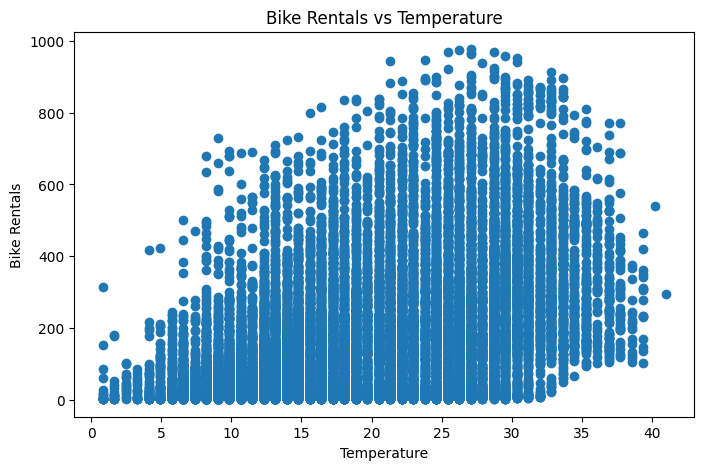

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["temp"], df["count"])
plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals vs Temperature")
plt.show()

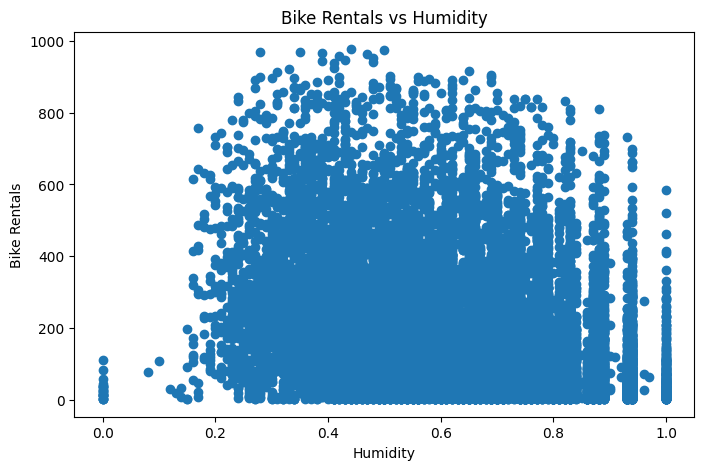

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["humidity"], df["count"])
plt.xlabel("Humidity")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals vs Humidity")
plt.show()

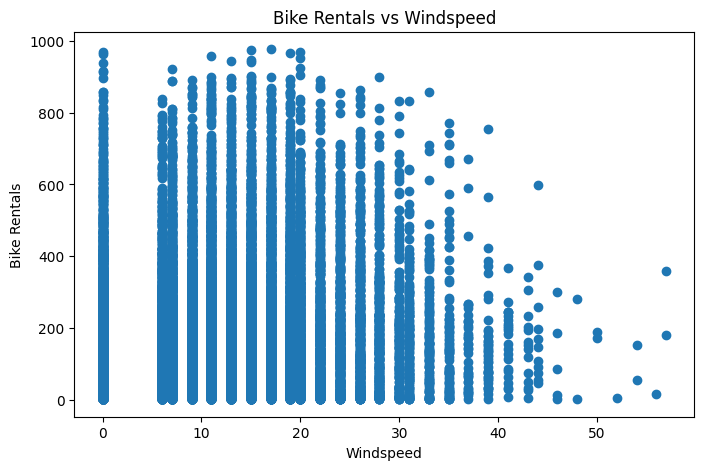

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["windspeed"], df["count"])
plt.xlabel("Windspeed")
plt.ylabel("Bike Rentals")
plt.title("Bike Rentals vs Windspeed")
plt.show()

#### First Impressions

The scatter plots reveal the following associations. There is a positive relationship between temperature and bike rentals. The relationship between humidity and bike rentals appears slightly negative, although not fully monotonic, and it is difficult to see a clear pattern. There seems to be a weak negative relationship between bike rentals, although there is a lot of noise and points are scattered.

The initial perception from the plots is that warmer temperatures encourage people to use bicycles and increase bike rentals. Higher humidity levels decrease comfort and lead to a slight decrease in bike rentals. Very low humidity levels, however, also discourage bike rentals. Wind speed discourages bike rentals, although the data exhibits significant variability.   

##### Correlation Matrix

We proceed with displaying a correlation matrix for better understanding of the relationship between the variables. 

In [2]:
!pip install seaborn

     ------------------------------------ 294.9/294.9 kB 958.5 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


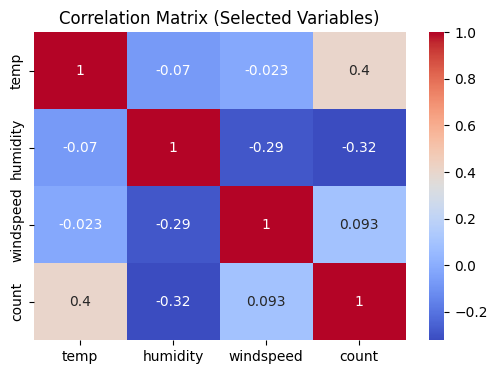

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# select relevant variables
df_corr = df[["temp", "humidity", "windspeed", "count"]]

# compute correlation matrix
corr = df_corr.corr()

# plot
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Selected Variables)")
plt.show()

The numbers above are Pearson correlation coefficients. 

The explanatory variables windspeed, temperature, and humidity exhibit moderate correlations (between 0.3 and 0.5 in magnitude). We do not have a severe multicollinearity problem and can include these variables in a regression analysis. 


##### Linear Regression Model

In the beginning we use a linear regression model to quantify the relationship between the weather conditions and bike rentals. The coefficients of the linear regression model show how changes in each of the explanatory variables affect bike rentals.



In [16]:
from sklearn.linear_model import LinearRegression

# Define variables
X = df[["temp", "humidity", "windspeed"]]   
y = df["count"]                          

# Fit model
model = LinearRegression()
model.fit(X, y)

# Coefficients
coefficients = list(zip(X.columns, model.coef_))
coefficients

[('temp', np.float64(8.84230287201673)),
 ('humidity', np.float64(-273.46510971885164)),
 ('windspeed', np.float64(0.39283325121705887))]

In [17]:
!pip install statsmodels

     ---------------------------------------- 9.6/9.6 MB 1.1 MB/s eta 0:00:00
     -------------------------------------- 233.3/233.3 kB 2.9 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import statsmodels.formula.api as smf

model = smf.ols("count ~ temp + humidity + windspeed", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  count   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     1945.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:18:35   Log-Likelihood:            -1.1253e+05
No. Observations:               17379   AIC:                         2.251e+05
Df Residuals:                   17375   BIC:                         2.251e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    175.8100      6.187     28.416      0.0

##### Interpretation of the linear regression results

The R-squared score of 0.251 indicates that the current model explains 25% of the variation in bike rentals. This is a moderate score (not high), indicating that there are other factors that impact bike rentals, different from weather conditions (ex. psychological factors, time of the day, whether the day is a working day, etc.). 

The coefficient for temperature is 8.84 and it is significant even at the 1% significance level (p-value = 0.00). This means that a one unit increase in temperature increases bike rentals by roughly 9 units, holding other factors in the model constant. The coefficient for humidity is -273.47 and it is significant at the 1% signicicance level (p-value = 0.00). We get such a large coefficient in magnitude because humidity is measured on a scale from 0 to 1. We interpret this as a 0.1 unit increase in humidity decreases bike rentals by roughly 27 units. The coefficient for windspeed is 0.39. It is significant at the 1% signicicance level (p-value = 0.01). A unit increase in windspeed increases bike rentals by 0.4. We could alternatively say that a 10 unit increase in windspeed increases bike rentals by 4.

